# Импорт библиотек и загрузка данных

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split, cross_validate
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import optuna
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score

c:\balon\pet_project\credit_fraud\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
files = {
    "test": "C:/balon/pet_project/credit_fraud1/datasets/test.csv",
    "train": "C:/balon/pet_project/credit_fraud1/datasets/train.csv",

}

df = {name: pd.read_csv(path) for name, path in files.items()}

train = df["train"]
test = df["test"]

In [17]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 219129 entries, 0 to 219128
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      219129 non-null  int64  
 1   Time    219129 non-null  float64
 2   V1      219129 non-null  float64
 3   V2      219129 non-null  float64
 4   V3      219129 non-null  float64
 5   V4      219129 non-null  float64
 6   V5      219129 non-null  float64
 7   V6      219129 non-null  float64
 8   V7      219129 non-null  float64
 9   V8      219129 non-null  float64
 10  V9      219129 non-null  float64
 11  V10     219129 non-null  float64
 12  V11     219129 non-null  float64
 13  V12     219129 non-null  float64
 14  V13     219129 non-null  float64
 15  V14     219129 non-null  float64
 16  V15     219129 non-null  float64
 17  V16     219129 non-null  float64
 18  V17     219129 non-null  float64
 19  V18     219129 non-null  float64
 20  V19     219129 non-null  float64
 21  V20     219129 non-nu

In [18]:
train.isnull().sum()

id        0
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [19]:
train.drop(["id"], axis=1, inplace=True)

In [20]:
train.describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T

,count,mean,std,min,25%,50%,75%,95%,max
Time,219129.0,62377.415376,25620.348569,0.000000,47933.000000,63189.000000,77519.000000,113163.000000,120580.000000
V1,219129.0,0.096008,1.395425,-29.807725,-0.846135,0.385913,1.190661,1.914220,2.430494
V2,219129.0,0.048345,1.159805,-44.247914,-0.573728,0.046937,0.814145,1.532125,16.068473
V3,219129.0,0.592102,1.132884,-19.722872,-0.027154,0.735895,1.306110,2.173558,6.145578
V4,219129.0,0.069273,1.253125,-5.263650,-0.769256,0.064856,0.919353,2.176670,12.547997
V5,219129.0,-0.161555,1.069530,-37.591259,-0.847346,-0.229929,0.356856,1.881268,34.581260
V6,219129.0,0.133688,1.202411,-25.659750,-0.631835,-0.087778,0.482388,3.268870,16.233967
V7,219129.0,-0.128224,0.817207,-31.179799,-0.646730,-0.098970,0.385567,1.012358,39.824099
V8,219129.0,0.149534,0.716212,-28.903442,-0.095948,0.111219,0.390976,0.979161,18.270586
V9,219129.0,-0.048337,1.054143,-8.756951,-0.711444,-0.131323,0.583715,1.822600,13.423914


In [21]:
train.duplicated().sum()

np.int64(0)

In [22]:
feature_number = (train.columns.to_list())
len(feature_number)
feature_number

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

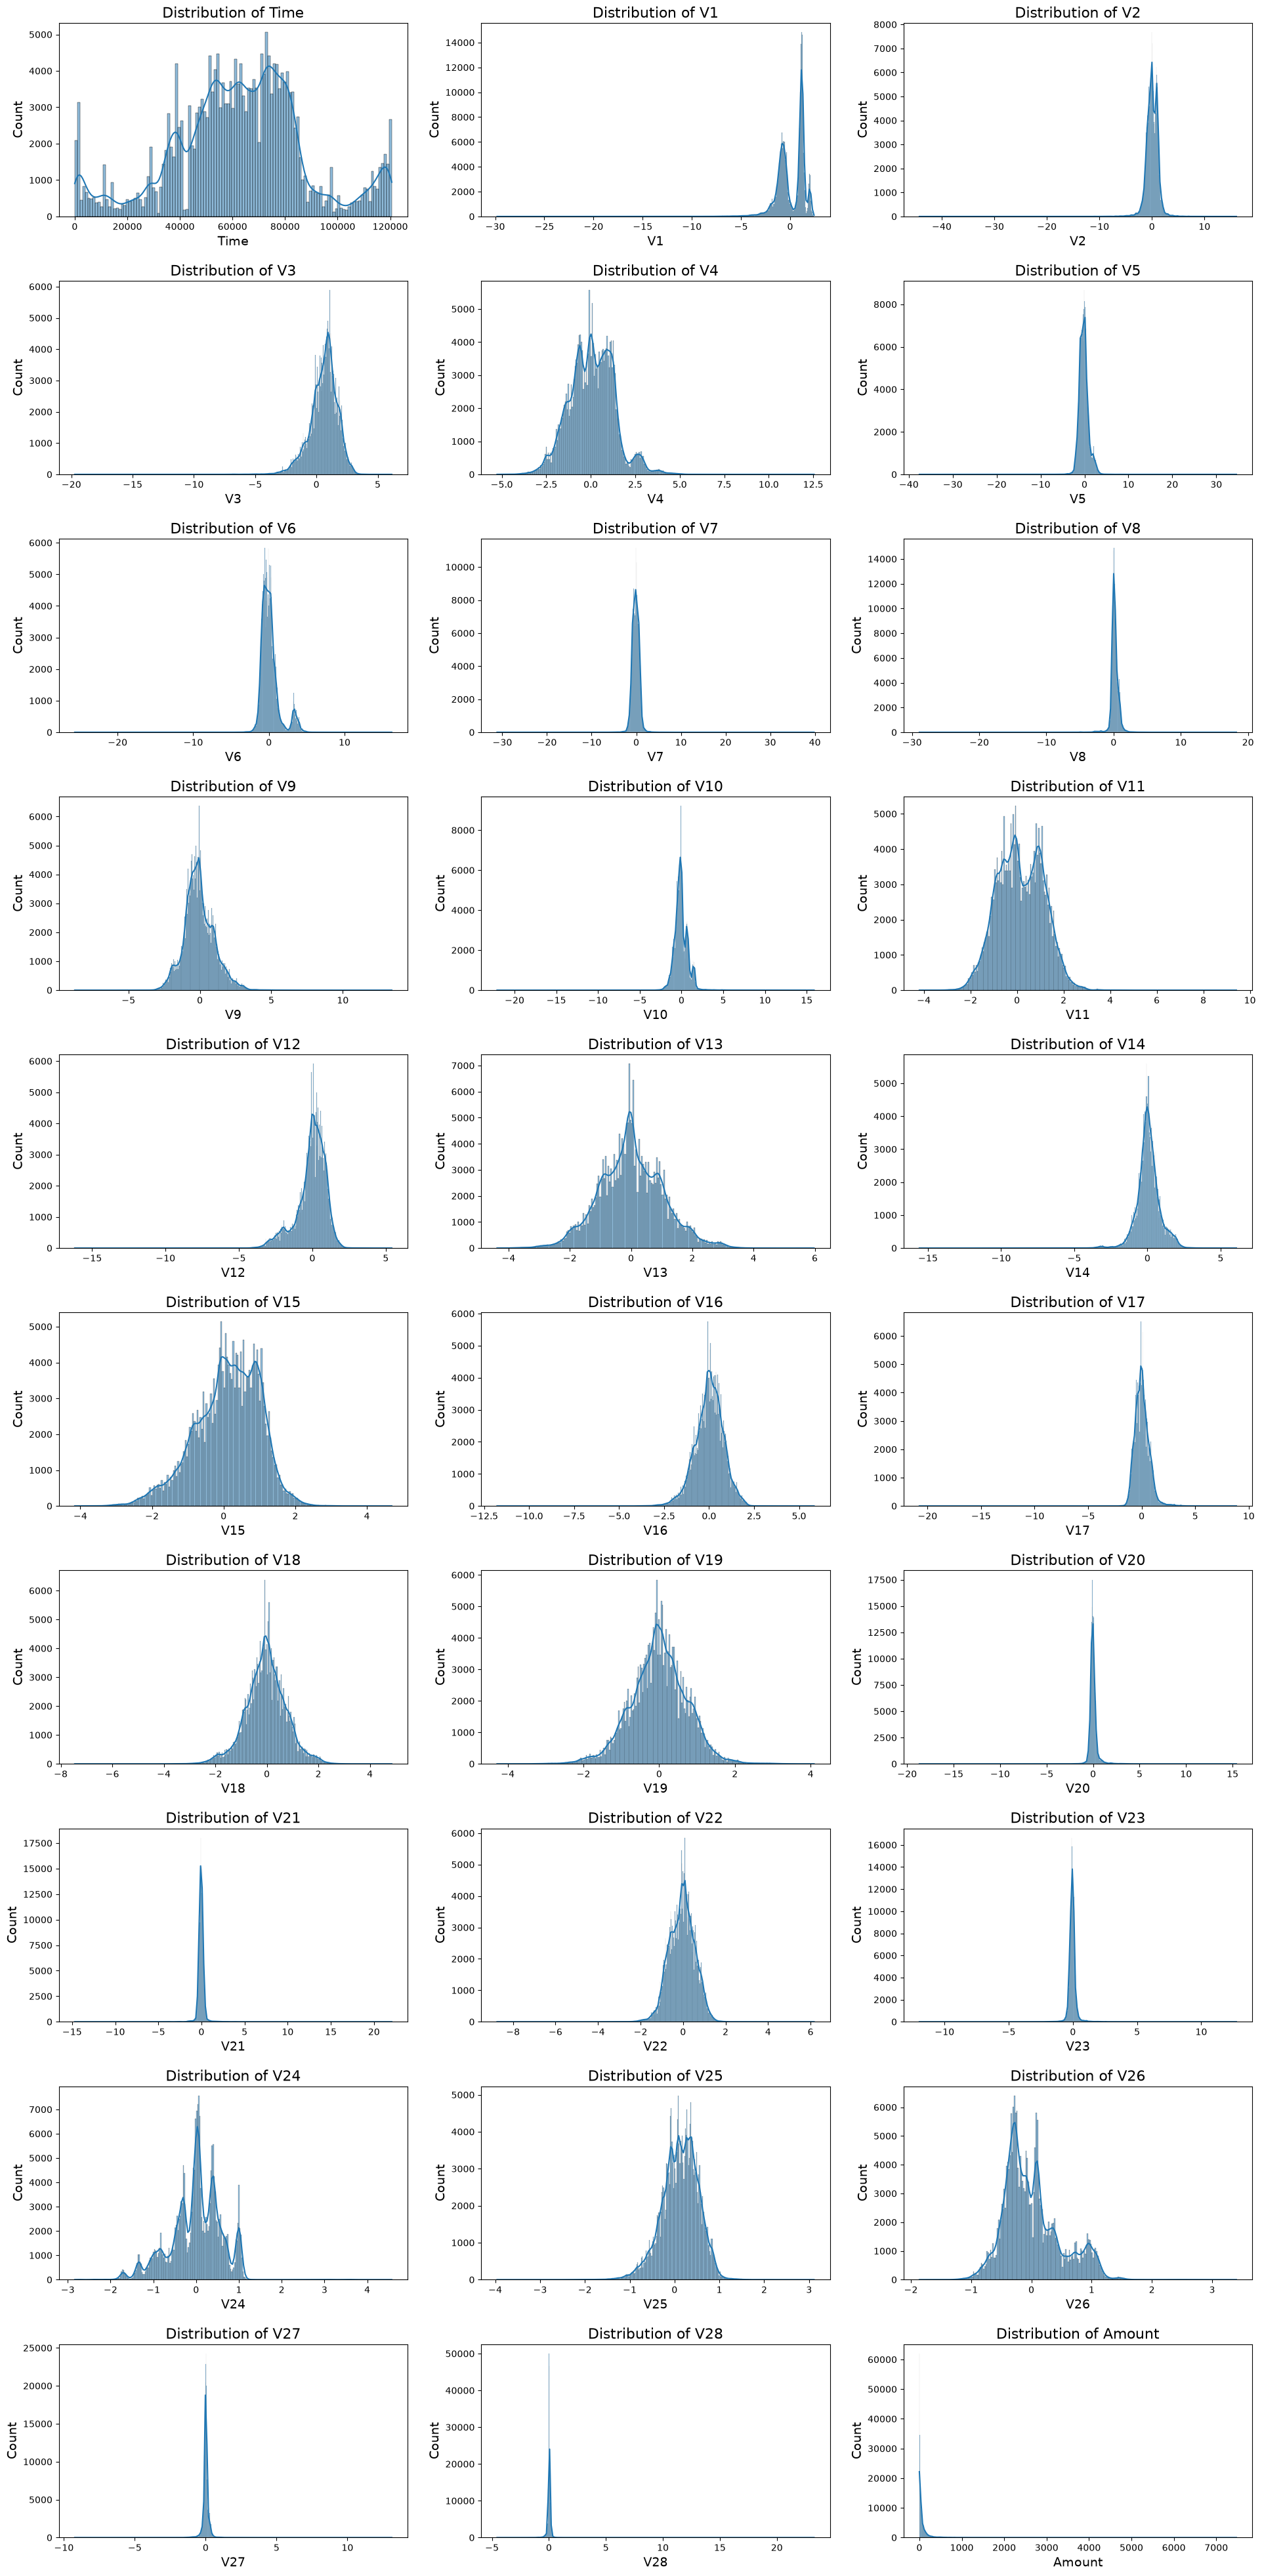

In [24]:
row,col = 10,3
fig,axis = plt.subplots(row, col, figsize=(20,40))
fig.tight_layout(pad=5.0)
col_num = 0
for i in range(row):
    for j in range(col):
        if(col_num > len(feature_number)-2):
            break
        sns.histplot(ax=axis[i,j], x=train[feature_number[col_num]], kde=True)
        axis[i,j].set_xlabel(feature_number[col_num], fontsize=14)
        axis[i,j].set_ylabel('Count', fontsize=14)
        axis[i,j].set_title(f'Distribution of { feature_number[col_num] }', fontsize=16)
        col_num += 1

In [26]:
#generating time features
train["day"] = (train["Time"]/ (3600 *24)).round(0)
train["hour"] = ((train["Time"]/3600)%24).round(0)

<Axes: xlabel='hour', ylabel='count'>

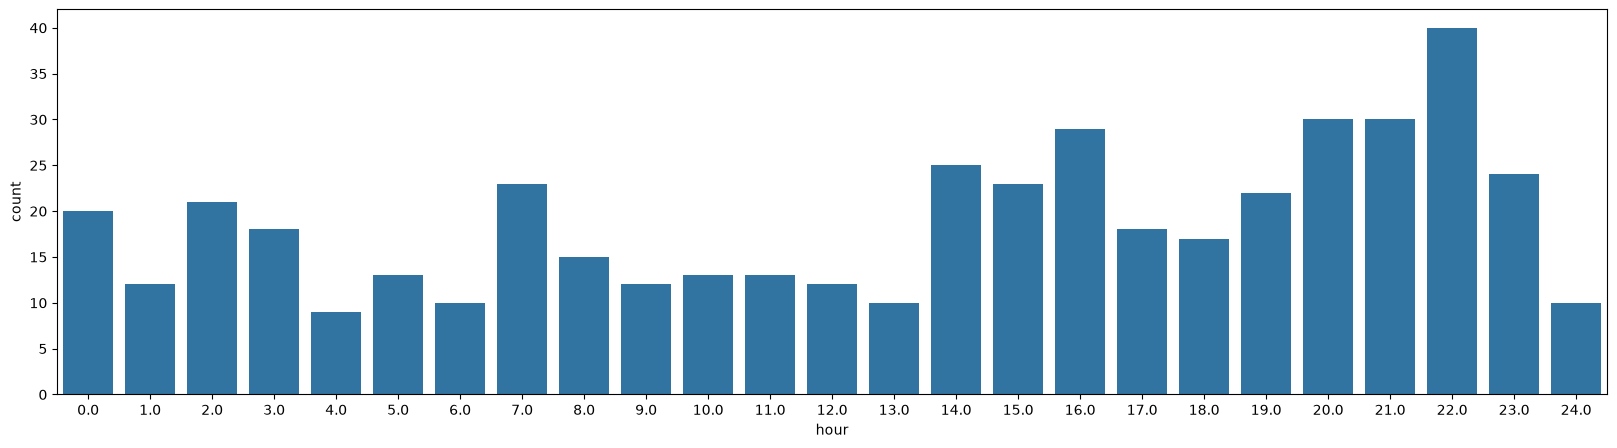

In [27]:
fraud = train[train["Class"] == 1]

fig,axis = plt.subplots(figsize=(20,5))
sns.countplot(x=fraud["hour"], ax=axis)

<Axes: >

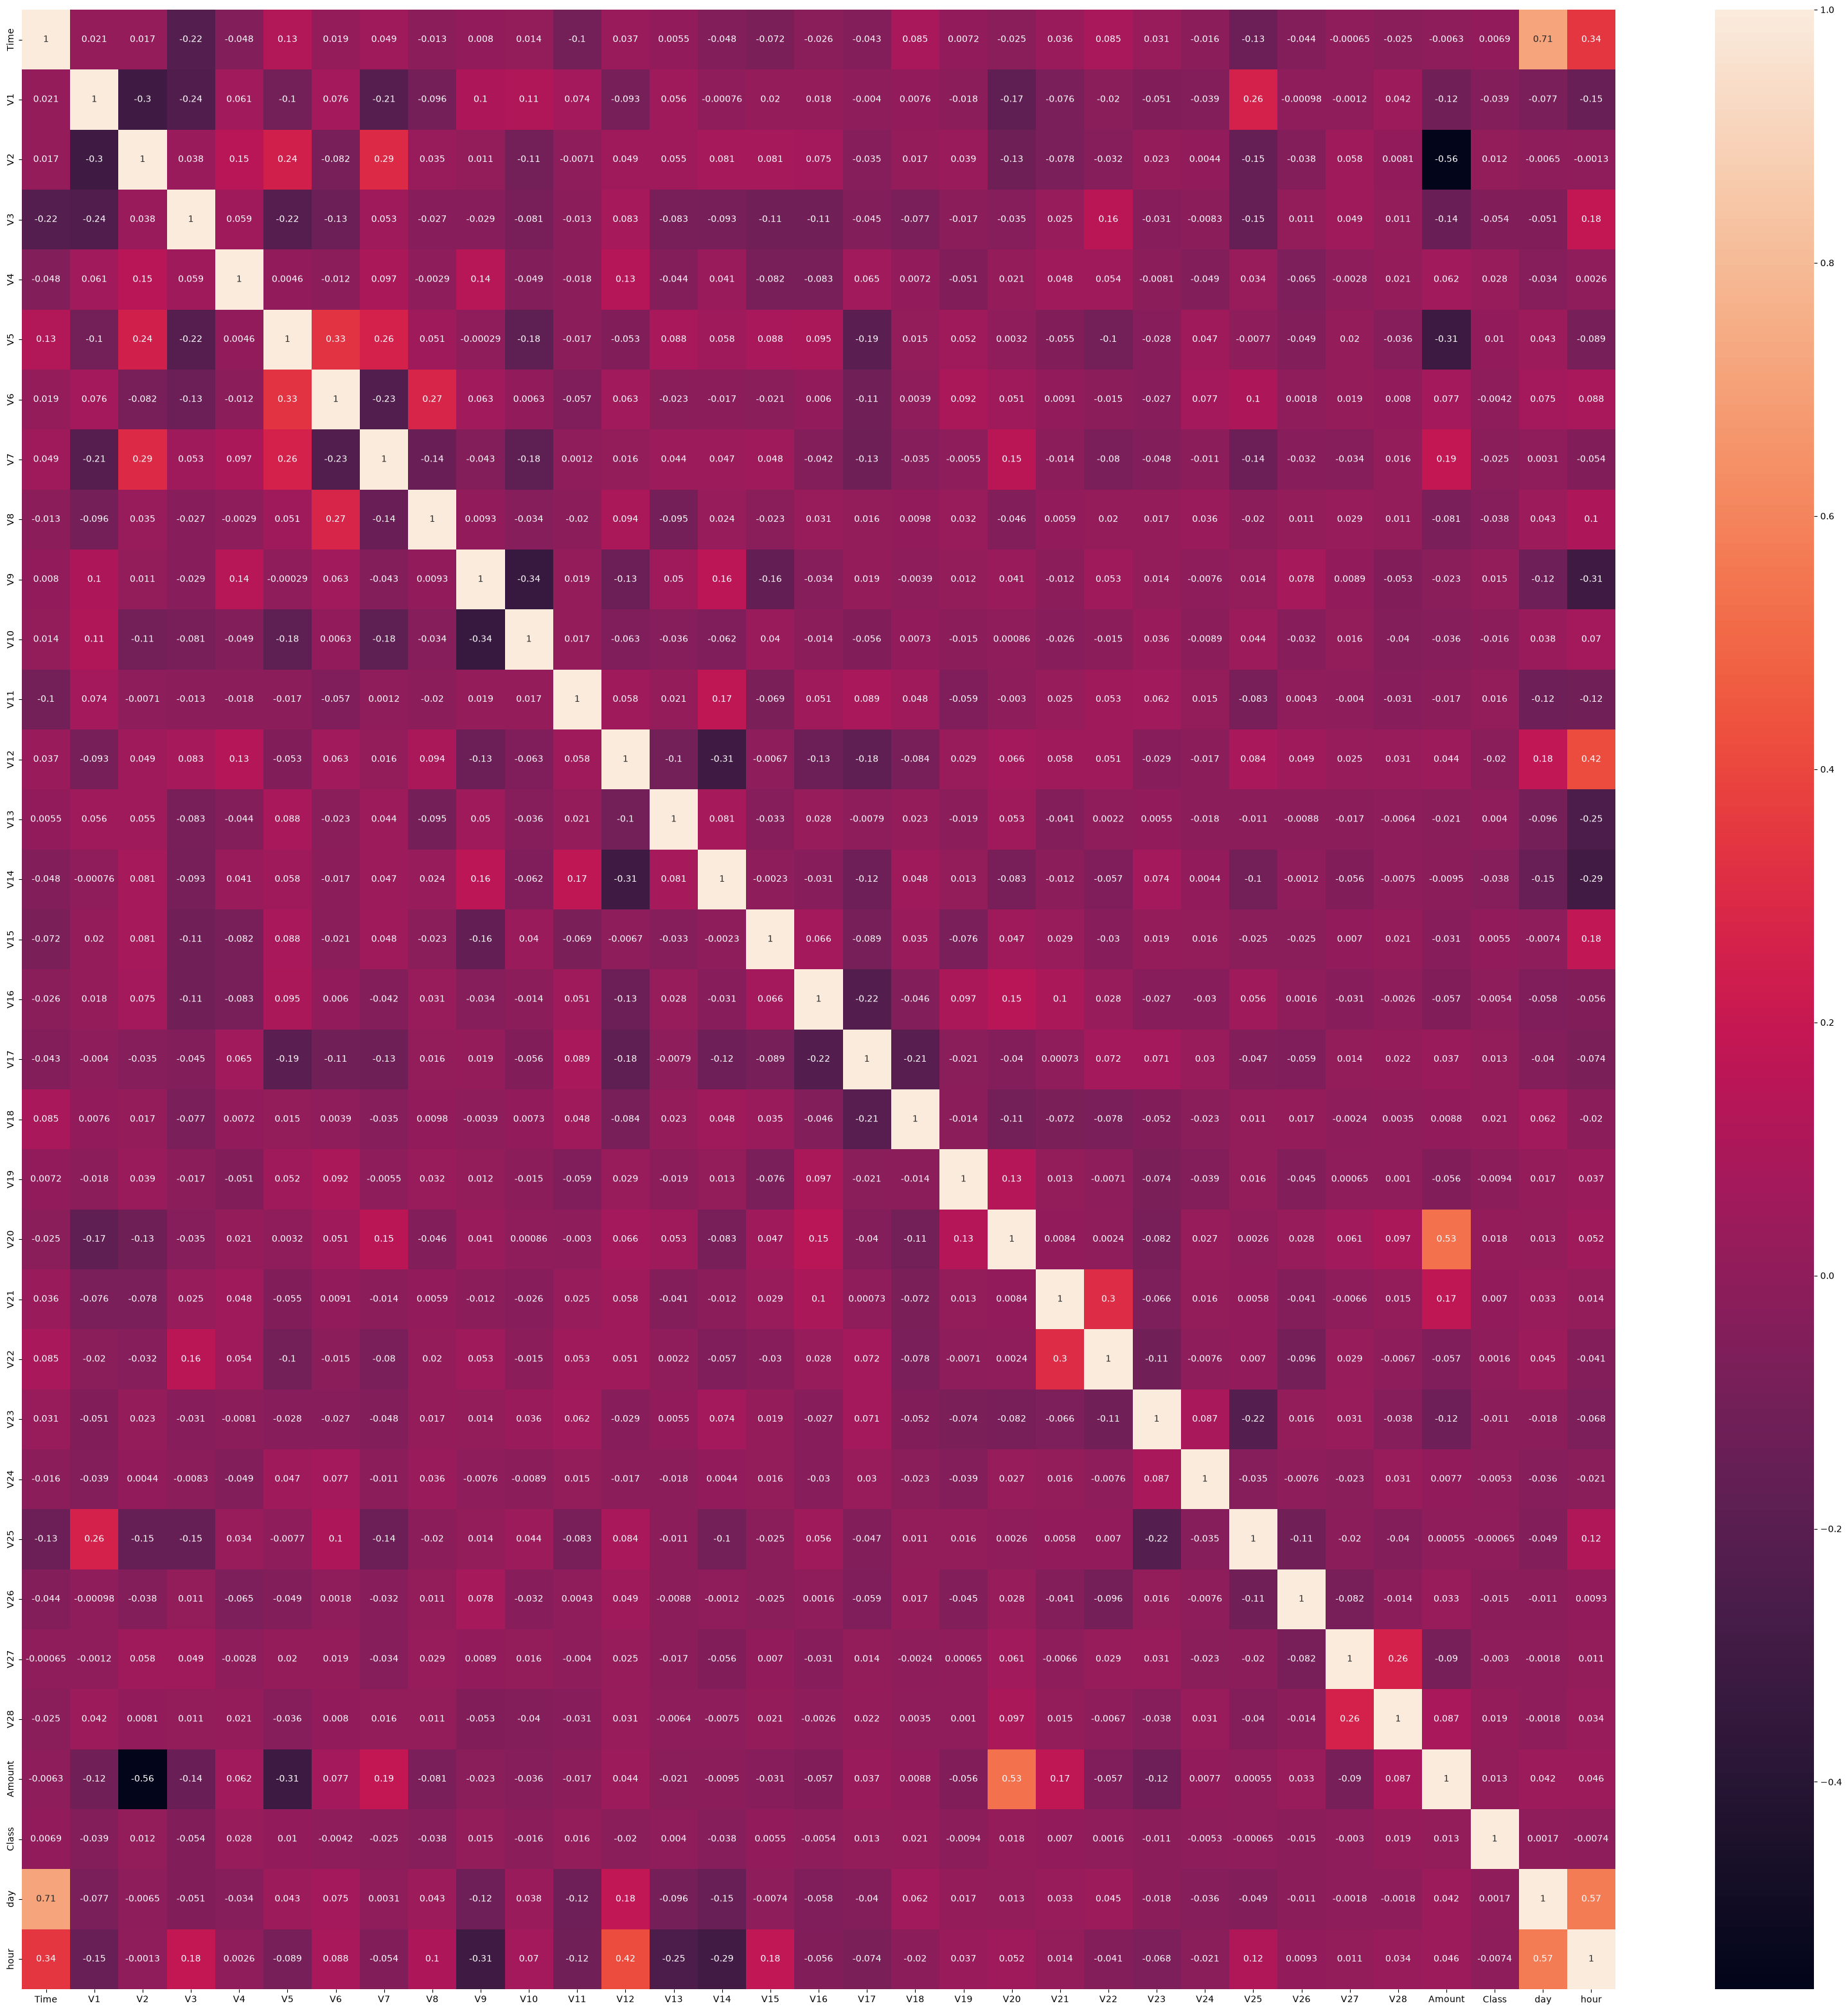

In [28]:
#Checking For Correlation
fig, axis= plt.subplots(figsize=(40,40))
sns.heatmap(train.corr(), annot=True, ax=axis)

In [29]:
def across_col_feat(df):

    features = [feat for feat in df.columns if 'V' in feat]
    df['V_Sum'] = df[features].sum(axis = 1)
    df['V_Min'] = df[features].min(axis = 1)
    df['V_Max'] = df[features].max(axis = 1)
    df['V_Avg'] = df[features].mean(axis = 1)
    df['V_Std'] = df[features].std(axis = 1)
    df['V_Var'] = df[features].var(axis = 1)
    
    return df
train = across_col_feat(train)
test  = across_col_feat(test)

In [30]:
X = train.drop(["Time","Class","id"], axis=1, errors="ignore")
y = train["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [31]:
#calculating class weights
weights = pd.DataFrame(compute_sample_weight('balanced', train['Class']), columns=['weight'])

#features to scale
scaleFeatures = X.columns.to_list()
rs = RobustScaler()
X[scaleFeatures] = rs.fit_transform(X[scaleFeatures])
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V28,Amount,day,hour,V_Sum,V_Min,V_Max,V_Avg,V_Std,V_Var
0,0.828957,-0.127074,-1.405058,0.206081,0.030967,-1.007308,0.203107,-0.769519,0.674409,0.237751,...,-1.068529,-0.316492,-1.0,-1.6,-0.917007,0.388817,0.458665,-0.917007,-0.360202,-0.329842
1,0.791888,-0.935120,-0.942697,-0.568157,-0.741237,-0.164319,-0.901212,-0.125319,0.016504,1.123157,...,-0.789575,0.986654,-1.0,-1.6,-0.619172,0.343888,0.370464,-0.619172,-0.044225,-0.043071
2,-0.144530,0.689963,-0.719543,-0.296164,0.745288,-0.808252,1.014356,-0.402544,0.068946,-0.788406,...,0.852209,-0.305211,-1.0,-1.6,-0.719784,0.633375,-0.791076,-0.719784,-0.749221,-0.632403
3,0.782472,-0.167080,-1.350146,0.032730,0.012200,-0.503536,0.010796,-0.301045,0.785356,0.109024,...,-1.254963,-0.332062,-1.0,-1.6,-0.409156,0.063891,0.348061,-0.409156,-0.387971,-0.353287
4,0.314211,-0.157625,0.350886,0.698234,-0.337687,1.065182,-0.813410,0.940641,0.636206,0.009450,...,-0.014546,-0.332062,-1.0,-1.6,0.829519,0.688176,-0.339126,0.829519,-0.382371,-0.348582


In [32]:
SEED = 0
#Defining Objective function
skfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0) 

def objective_xgb(eg):
    
    params = {
        "verbosity":0,
        "objective":"binary:logistic",
        'tree_method': 'gpu_hist',
        'predictor': 'gpu_predictor',
        "eval_metric":"auc",
        "lambda":eg.suggest_float("lambda", 0.01, 10),
        "alpha":eg.suggest_float("alpha", 0.01, 10),
        "max_depth": eg.suggest_int("max_depth", 1, 20),
        "subsample": eg.suggest_categorical('subsample', [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]),
        "colsample_bytree": eg.suggest_categorical('colsample_bytree', [0.2, 0.4, 0.6, 0.8, 1.0]),
        "learning_rate": eg.suggest_categorical("learning_rate", [0.01, 0.02, 0.03, 0.05, 0.07, 0.09, 0.1]),
        "n_estimators": eg.suggest_int("n_estimators",100,2000),
        "early_stopping":100,
        "random_state":SEED,
        "sample_weight":weights
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    scores = cross_validate(model, X, y, cv=skfold, scoring="roc_auc")
    return roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

    return score

In [33]:
#Generating Study
study = optuna.create_study(direction="maximize")
optuna.logging.set_verbosity(optuna.logging.INFO)
#study.optimize(objective_xgb, n_trials=20)

[I 2026-10-05 14:13:42,023] A new study created in memory with name: no-name-30e0bad6-a275-4848-95df-0bcb13750ecd


In [36]:
#display(study.best_value)
#display(study.best_params)

In [38]:
#Training XGBoost with best params
best_params = {'lambda': 3.3505139360015495,
 'alpha': 6.403269527191655,
 'max_depth': 11,
 'subsample': 0.8,
 'colsample_bytree': 0.2,
 'learning_rate': 0.05,
 'n_estimators': 366}

gpu_params = {
    "objective":"binary:logistic",
    'tree_method': 'hist', 
    'device': 'cuda',
    'predictor': 'gpu_predictor',
    "eval_metric":"auc",
    "sample_weight":weights
}

params =  {**best_params, **gpu_params}

model = XGBClassifier(**params)
model.fit(X_train, y_train)
folds = 5
cv_results =  cross_validate(model, X_train, y_train, scoring='roc_auc', cv=skfold)
display(roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

c:\balon\pet_project\credit_fraud\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:19:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\balon\pet_project\credit_fraud\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:19:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\balon\pet_project\credit_fraud\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:19:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "predictor", "sample_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\balon\pet_project\credit_fraud\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:19:31] WARNING: C:\actions-runner\_work\xgboo

0.8362847167694545

# Test

In [40]:
X_test = test.drop(["id","Time"], axis=1, errors="ignore")
X_test["day"] = (test["Time"]/ (3600 *24)).round(0)
X_test["hour"] = ((test["Time"]/3600)%24).round(0)
X_test  = across_col_feat(X_test)
X_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V28,Amount,V_Sum,V_Min,V_Max,V_Avg,V_Std,V_Var,day,hour
0,2.115519,-0.691809,-1.305514,-0.685655,-0.641265,-0.764784,-0.924262,-0.023030,-0.230126,0.220610,...,-0.021944,29.95,-1.186785,-2.243711,2.115519,-0.028942,1.036428,1.081198,1.0,9.0
1,1.743525,-1.681429,-0.547387,-1.061113,-0.695825,2.458824,-1.632859,1.073529,1.068183,0.483337,...,0.064690,163.50,19.851183,-1.681429,19.851183,1.420653,4.804329,23.406844,1.0,9.0
2,2.205568,-1.571445,-0.238965,-1.662517,-1.652324,-0.054701,-1.682064,0.105613,-1.177858,1.626352,...,-0.037855,16.00,-5.215153,-5.215153,2.205568,-0.302982,1.557565,2.486710,1.0,9.0
3,1.989728,-0.972909,-1.938259,-1.440129,-0.166855,-0.794048,0.252889,-0.399789,2.079398,-1.225592,...,-0.036143,120.98,-1.380691,-1.938259,2.079398,-0.030623,1.082432,1.177416,1.0,9.0
4,-1.943548,-1.668761,0.363601,-0.977610,2.684779,-2.037681,0.039709,-0.048895,-0.281749,-0.341879,...,0.335537,1.98,-10.647000,-10.647000,2.684779,-0.690467,2.718638,7.662374,1.0,9.0


In [41]:
X_test[scaleFeatures] = rs.transform(X_test[scaleFeatures])
X_test

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V28,Amount,V_Sum,V_Min,V_Max,V_Avg,V_Std,V_Var,day,hour
0,0.849180,-0.532287,-1.531137,-0.444456,-0.341584,-0.607604,-0.799471,-0.275708,-0.076286,0.361519,...,-0.576581,0.127900,-0.519741,-0.750837,0.506783,-0.445029,0.961534,1.130345,0.0,-0.7
1,0.666543,-1.245335,-0.962512,-0.666803,-0.386892,2.285540,-1.485899,1.976307,0.926145,0.652297,...,0.555915,2.249762,3.655973,-0.130842,21.225373,7.611196,14.151312,51.507226,0.0,-0.7
2,0.893391,-1.166089,-0.731183,-1.022957,-1.181193,0.029686,-1.533565,-0.011512,-0.808036,1.917351,...,-0.784577,-0.093740,-1.319311,-4.027273,0.611977,-1.968024,2.785807,4.301824,0.0,-0.7
3,0.787420,-0.734827,-2.005721,-0.891258,0.052378,-0.633868,0.340851,-1.049463,1.706911,-1.239093,...,-0.762196,1.574198,-0.558229,-0.414033,0.464587,-0.454371,1.122573,1.347458,0.0,-0.7
4,-1.143689,-1.236207,-0.279235,-0.617352,2.420448,-1.750011,0.134340,-0.328828,-0.116145,-0.261027,...,4.096484,-0.316492,-2.397449,-10.016654,1.171786,-4.121500,6.850219,15.980492,0.0,-0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146082,-0.514410,-0.482694,-0.000236,-0.366529,0.913316,-0.270793,0.252056,-0.084766,0.640965,-0.611935,...,3.366667,1.158405,-2.613586,-11.217361,-0.948347,-4.762160,7.296246,17.728948,1.0,0.8
146083,-0.238022,0.515150,-0.296927,-0.387539,0.786430,-0.157049,0.799423,-0.373420,0.175485,-0.741585,...,3.045852,0.049094,1.200436,0.477133,6.773234,2.660740,3.829903,6.576764,1.0,0.8
146084,-0.919990,1.240896,-0.138175,0.175712,0.237730,0.154926,0.645663,-0.351426,0.357507,1.914281,...,0.637593,0.128535,3.405396,0.082532,19.750598,7.167500,12.840792,43.553309,1.0,0.8
146085,-1.117388,-0.145406,-0.500575,-1.167719,-1.256644,0.722716,1.046771,-0.659103,-0.327963,-0.195889,...,-2.325431,4.640928,-3.239047,-14.691982,-0.352763,-5.981653,10.038105,29.632848,1.0,0.8
